# Project Title

# 🛒Saudi Hypermarket Retail Performance & Customer Insights Analytics



## 🎯 Objective (Problem Statement)

🧹 Data Cleaning & Preprocessing: Identify and clean missing values, duplicate records, and data type inconsistencies across all branch records.

📊 Sales & Revenue Optimization: Analyze total revenue (~29M SAR) across 35 branches and 12 regions to identify top-performing market locations.

📦 Product & Payment Trends: Evaluate high-demand product categories (e.g., Fresh Produce, Meat & Poultry) and customer payment preferences (Mada, Cash, Credit Card).

⭐ Customer Satisfaction Analysis: Measure customer satisfaction scores across different store sizes (Large, Medium, Small) to improve overall service quality.

💡 Actionable Business Insights: Provide data-backed recommendations to optimize store operations, inventory allocation, and marketing strategies

# 🏆 Outcome

✨ This project delivers a comprehensive analytical study of Saudi Hypermarket's performance across various branches and regions from 2024 to 2026. Through systematic Data Cleaning, Exploratory Data Analysis (EDA), and Visualizations, the project uncovers critical revenue drivers, regional consumer behavior, top-performing product categories, and payment channel preferences. These insights enable executive stakeholders to make evidence-based operational decisions, optimize inventory, and enhance overall profitability

**🌐 Domain & Dataset Details**

🌐 Domain: Retail & Hypermarket Operations Analytics, Supply Chain & Financial Management (KSA Region)

📊 Dataset Name: Saudi Hypermarket Branch Performance 2024–2025

🔗 Dataset Source: [Saudi Hypermarket Branch Performance 2024–2026](https://prime-levels.com/data-hub/saudi-hypermarket-branch-performance-2024-2026)

📑 Data Format: CSV

🎯 Primary Scope: Branch-level sales performance, daily transaction logs, product category performance, billing, operating costs, and profit tracking across Saudi Arabia in Saudi Riyals (SAR)

**📁 Dataset Structure Information**

📁 File Name: saudi_hypermarket_performance.csv

🔗 Dataset Source: Prime Levels Data Hub

📊 Total Rows: 3,000

📐 Total Columns: 10

🗓️ Analysis Years:  Data collected from January 2024 to May 2026

**📋 Column / Features Description:**

📅 transaction_date: The date when the transaction record was generated (DD-MM-YYYY).

🏪 branch_name: Name of the hypermarket branch (e.g., Jeddah North, Riyadh South, Arar Central).

📍 region: Administrative region in Saudi Arabia (e.g., Riyadh, Makkah, Eastern Province).

🏬 branch_size: Physical size category of the store footprint (Large, Medium, Small).

🥗 product_category: Main category of goods sold (e.g., Fresh Produce, Meat & Poultry, Beverages).

💰 total_revenue_sar: Total sales revenue generated in Saudi Riyal (SAR).

💳 number_of_transactions: Total count of transactions recorded for that period.

🛍️ average_basket_sar: Average spend per transaction calculated in SAR.

🪙 payment_method: Payment method utilized by the customer (Mada, Cash, Credit Card).

⭐ customer_satisfaction_score: Average customer feedback score (Scale: 1.0 to 5.0)

# 🚀 Stages for Data Analytics Project

**📌 Stage 1 – Problem Definition and Dataset Selection**

📝  Business Problem & Expected Outcome
❓ Business Problem: Operating hypermarkets across multiple regions in Saudi Arabia requires clear visibility into sales trends, customer preferences, and store operational efficiency. Managing 35+ branches without data-driven tracking leads to inventory imbalances and lost revenue opportunities.

🎯 Expected Outcome: Clear identification of revenue drivers, high-margin categories, customer payment trends, and satisfaction levels to guide expansion and stock planning.

# 🔍  Initial EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# load data
df = pd.read_csv("Saudi Hypermarket Branch Performance.csv")


In [ ]:
df

# Data Inspection

In [ ]:
df.head(5)

**Dataset Overview & Structural Inspection**

In [ ]:
##DATA DIMENSION
df.shape

In [ ]:
##DATA INFORMATION
df.info()

In [ ]:
df.describe()

# Categorical Features Exploration

In [ ]:
df.columns.tolist()

# Missing value and duplicate record check

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

# Stage 2: Data Cleaning & Pre-processing

**Handling Missing Value**

**Numerical columns using Median**

I used Median Imputation to fill missing values in numerical columns.
This prevents outliers from distorting the overall data distribution.

In [ ]:


df.fillna({
    'total_revenue_sar': df['total_revenue_sar'].median() if 'total_revenue_sar' in df else None,
    'number_of_transactions': df['number_of_transactions'].median() if 'number_of_transactions' in df else None,
    'average_basket_sar': df['average_basket_sar'].median() if 'average_basket_sar' in df else None,
    'customer_satisfaction_score': df['customer_satisfaction_score'].median() if 'customer_satisfaction_score' in df else None
}, inplace=True)

**Categorical columns using Mode**

I applied Mode Imputation for missing values in categorical columns.
This replaces missing text values with the most frequently occurring category.

In [ ]:


df.fillna({
    'branch_size': df['branch_size'].mode()[0],
    'product_category': df['product_category'].mode()[0],
    'payment_method': df['payment_method'].mode()[0]
}, inplace=True)

In [ ]:
print("Missing values count after imputation:")
print(df.isnull().sum())

# Handle Duplicates

I checked for duplicate records and removed them to clean the dataset.
This avoids repeated data entries and ensures high accuracy in model training.

In [ ]:
# Check the total count of duplicate rows
print("Duplicate rows count removing:", df.duplicated().sum())

# Column name rename or dropping unwanted columns if required

I converted all column names to lowercase and replaced spaces with underscores.
I also renamed complex column names to simpler terms like 'sat_score' for easier coding.

In [ ]:
# Standardiztion column names (convert to lowercase and replace spaces with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
# Rename specific column for convenience
df.rename(columns={'customer_satisfaction_score': 'sat_score'}, inplace=True)

In [ ]:
print (df.rename)

In [ ]:
# Drop unwanted column
df = df.drop(columns=['number_of_transactions.1'], errors='ignore')

# Verify remaining columns after dropping
print("Remaining columns after drop:")
print(df.columns.tolist())

# Treat outliers if required

I applied the Interquartile Range (IQR) method to detect extreme revenue values.
Data points beyond the 1.5 times IQR boundaries were filtered out to maintain consistency.

In [ ]:
# Treat outliers if required
Q1 = df["total_revenue_sar"].quantile(0.25)
Q3 = df["total_revenue_sar"].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers outside the lower and upper bounds
df = df[~((df["total_revenue_sar"] < (Q1 - 1.5 * IQR)) | (df["total_revenue_sar"] > (Q3 + 1.5 * IQR)))]

print(IQR)

# Check skewness and apply transformations

I checked the skewness of the total revenue column, which was right-skewed.
I applied Log Transformation to convert the skewed revenue into a normal distribution.

In [ ]:
# Check skewness for numerical features
print("Skewness before transformation:")
print(df[["total_revenue_sar","number_of_transactions"]].skew())

In [ ]:
import numpy as np

# Direct Log Transformation on total revenue column
df["total_revenue_sar_log"] = np.log(df["total_revenue_sar"])

# Print updated dataframe sample with new log column
print(df[["total_revenue_sar", "total_revenue_sar_log"]].head())

# Convert data types if needed






I converted the transaction count column from float to integer since transaction counts cannot be decimal values.
Then I verified the updated data types to ensure accurate data representation.

In [ ]:
# Convert number_of_transactions float to integer
df['number_of_transactions'] = df['number_of_transactions'].astype(int)

In [ ]:
# Verify updated data types
print("Data types after conversion:")
print(df[['transaction_date', 'number_of_transactions']].dtypes)

# Feature transformations (date parts, derived fields if required for analysis)



**Date Feature Extraction**

I converted the transaction date string to datetime format and extracted the year, month, and day name.
This helps analyze time-based trends and sales performance across different days and months.

In [ ]:
import pandas as pd

# Convert transaction_date string using mixed format
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', dayfirst=True)

# Extract year, month, and day_name
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_name'] = df['transaction_date'].dt.day_name()

# Check extracted date features
print("Extracted Date Parts:")
print(df[['transaction_date', 'year', 'month', 'day_name']].head())

In [ ]:
# Create derived field: Revenue per Transaction (Division Method)
df["rev_per_trans"] = df["total_revenue_sar"] / df["number_of_transactions"]

# Inspect derived feature
print("Derived Feature (rev_per_trans):")
print(df[['total_revenue_sar', 'number_of_transactions', 'rev_per_trans']].head())

**Revenue Category Binning**

I segmented overall revenue into LOW, MEDIUM, and HIGH financial tiers using boundary cutoffs.
This enables performance profiling and categorization of low-value versus high-value branches.

In [ ]:
# Create categorical column using pd.cut() (3 bins: LOW, MEDIUM, HIGH)
df["revenue_category"] = pd.cut(
    df["total_revenue_sar"],
    bins=[0, 5000, 10000, float("inf")],
    labels=["LOW", "MEDIUM", "HIGH"]
)

# Inspect binned feature
print("Revenue Category (Binning):")
print(df[['total_revenue_sar', 'revenue_category']].head())

In [ ]:
# Date conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', dayfirst=True)
print(df['transaction_date'])



**Financial Quarter Extraction**

I extracted the financial quarter from the transaction date and converted it to string format.
This enables quarter-over-quarter financial performance analysis and reporting.

In [ ]:

df['quarter_period'] = df['transaction_date'].dt.to_period('Q').astype(str)
print (df['quarter_period'])



**Saudi Weekend Flag Identification**

I created a binary weekend flag specifically for Saudi Arabia where Friday and Saturday are weekend days.
This separates weekend transactions from weekday sales for consumer pattern analysis.

In [ ]:
# Saudi Weekend Flag (Friday=4, Saturday=5)
df['weekends'] = df['transaction_date'].dt.dayofweek.isin([4, 5]).astype(int)
print (df['weekends'])

**CSAT Rating Binning**

I categorized customer satisfaction scores into Low CSAT, Medium CSAT, and High CSAT tiers.
This bins continuous satisfaction scores into clear feedback levels for customer experience tracking.

In [ ]:

df['csat_category'] = pd.cut(
    df['sat_score'],
    bins=[0, 3.0, 4.0, 5.0],
    labels=['Low CSAT', 'Medium CSAT', 'High CSAT']
)
print(df['csat_category'])

**Digital Payment Indicator**

I generated a binary flag to identify digital payments like Mada, Credit Card, and Apple Pay versus cash.
This helps track customer adoption of digital and contactless payment methods.

In [ ]:

df['digital_payment'] = df['payment_method'].apply(
    lambda x: 1 if str(x).strip().lower() in ['mada', 'credit card', 'apple pay'] else 0
)
print (df['digital_payment'])

**Revenue Per Transaction**

I calculated the revenue per transaction by dividing total revenue by transaction count and rounding to 2 decimals.
This feature serves as a Key Performance Indicator (KPI) to evaluate average sale value per customer visit.

In [ ]:

df['rev_per_trans'] = (df['total_revenue_sar'] / df['number_of_transactions']).round(2)
print(df["rev_per_trans"])

# 📊 Stage 3: Exploratory Data Analysis (EDA) & Data Visualization



Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

**Interpretation MUST with every visualization**

Focus on business story not just charts

Each chart must be in seperate cells.

#**Univariate Analysis**




**Distribution of Total Revenue**

In [ ]:
#Histogram


plt.figure(figsize=(9, 5))

sns.histplot(df["total_revenue_sar"], kde=True, color="skyblue", bins=30)

plt.title("Distribution of Total Revenue (SAR)", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (SAR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
  * Summarizes the distribution, skewness, and overall revenue range of transactions.

Diagnostic Analysis
  * Explains the bimodal shape due to differing shopping intents (quick trips vs. major restocking).

Predictive Analysis
  * Indicates future daily sales will consistently group around the two major revenue peaks.

Prescriptive Analysis
  * Introduce product bundles in the 7,000–10,000 SAR gap to incentivize mid-tier shoppers to spend more.

# Interpretation

* A histogram with a KDE curve showing the frequency distribution of total transaction revenues.
* Spending is bimodal, with major peaks at low (2k-5k SAR) and high (12k-15k SAR) purchase values.
* `total_revenue_sar` on the X-axis and `Frequency` (transaction count) on the Y-axis.
* Customers split into routine buyers and bulk shoppers, showing a mid-tier growth opportunity (7k-10k SAR).

# Insights

* Most transactions cluster around ~2,000–5,000 SAR and ~12,000–15,000 SAR revenue brackets
* A revenue dip occurs between 7,000–10,000 SAR, highlighting a strong opportunity for bundle offers to increase basket size
* Customer spending naturally splits into two distinct groups: frequent routine buyers and large bulk shoppers

# Outlier and Range Detection in Number of Transactions

In [ ]:
#Boxplot


plt.figure(figsize=(8, 4))
sns.boxplot(x=df["number_of_transactions"], color="purple")

plt.title(
    "Outlier and Range Detection in Number of Transactions",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of Transactions")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes the distribution, interquartile range (IQR), median, and overall spread of transaction counts.

Diagnostic Analysis
* Identifies extreme transaction values (outliers) that deviate significantly from standard store performance.

Predictive Analysis
* Indicates that most regular operational days will naturally record transactions within the normal 50 to 140 range.

Prescriptive Analysis
* Investigate high-volume outlier days (>270 transactions) to understand promotional or seasonal drivers and replicate success.






# Interpretation

* A horizontal boxplot showing the median, quartiles, and extreme outlier values for store transactions.
* Most daily transaction counts fall between 50 and 140, with a median around 100 transactions.
* `number_of_transactions` on the X-axis as the core numeric feature.
* Displays a right-skewed distribution with multiple high-value outliers extending beyond 270 transactions up to ~370.


# Insights

* Normal store operations consistently generate between 50 and 140 transactions per observed period.
* Several extreme outlier events exceed 270 transactions, likely representing festive sales, promotions, or bulk buying days.
* Data cleaning/capping or separate modeling may be required for outliers to prevent bias in predictive algorithms.

# Customer Satisfaction Score Distribution

In [ ]:
# Count Plot

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="sat_score",
    palette="viridis",
    order=sorted(df["sat_score"].dropna().unique()),
)
plt.title(
    "Customer Satisfaction Score Distribution", fontsize=14, fontweight="bold"
)
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis:
* Summarizes the frequency distribution, central tendency, and overall spread of Customer Satisfaction (CSAT) scores

Diagnostic Analysis
* Explains customer satisfaction levels, showing that most customers rate store services around a moderate-to-high score of 3.8

Predictive Analysis
* Indicates future CSAT ratings will likely cluster between 3.5 and 4.2 based on current service performance

Prescriptive Analysis
* Focus on service improvements to shift scores from the 3.5–3.8 range toward 4.5+ for higher customer retention







# Interpretation

* A count bar chart showing the frequency distribution of individual CSAT scores
* Scores peak prominently at 3.8, with the majority falling between 3.5 and 4.2
* `sat_score` on the X-axis and `Count` on the Y-axis
* Displays a left-centered normal distribution with very few ratings below 2.7 or above 4.7

# Insights

* Most customers are generally satisfied, with ratings heavily concentrated around 3.6 to 4.0
* Very low satisfaction ratings (<3.0) are minimal, indicating consistent overall operational standards
* Perfect or near-perfect ratings (4.8–5.0) are rare, highlighting clear scope for service enhancement

# Distribution OF Records Across Regions

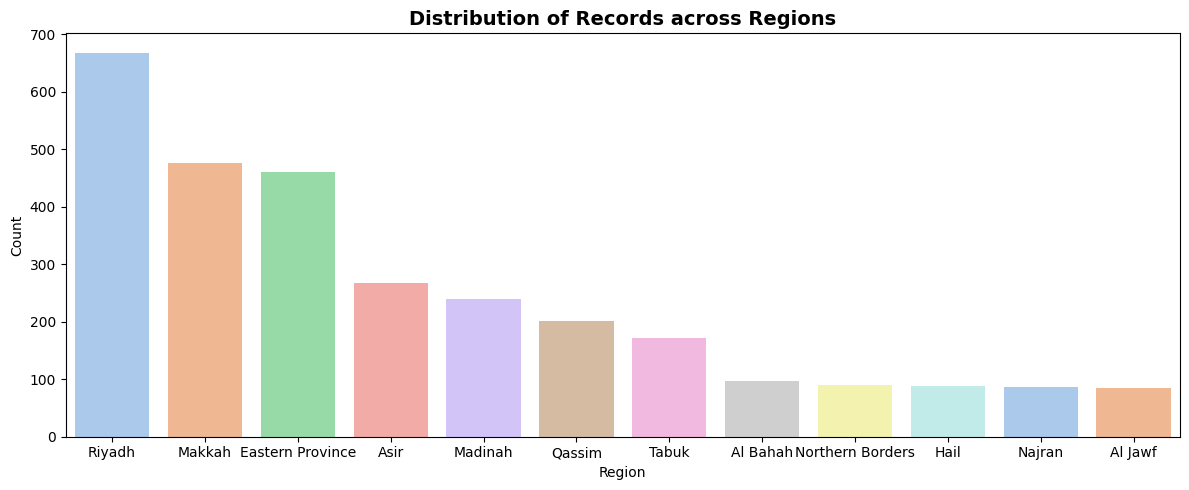

In [48]:
#Countplot
# TRANSACTION COUNT BY REGION


plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    x="region",
    palette="pastel",
    order=df["region"].value_counts().index,
)

plt.title(
    "Distribution of Records across Regions", fontsize=14, fontweight="bold"
)
plt.xlabel("Region")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes the categorical distribution and transaction volume counts across various geographic regions

Diagnostic Analysis
* Highlights regional market dominance, showing high transaction density in major economic hubs like Riyadh, Makkah, and Eastern Province

Predictive Analysis
* Indicates that future sales volume will continue to be heavily driven by top-tier regions compared to smaller provinces

Prescriptive Analysis
* Focus marketing campaigns and supply chain expansion on tier-2 regions (Asir, Madinah, Qassim) to grow market share






# Interpretation

* A categorical bar chart illustrating total transaction records across different Saudi regions
* Riyadh leads significantly with the highest count (670 records), followed by Makkah and Eastern Province (450–480 records)
* `Region` on the X-axis and `Count` on the Y-axis
* Shows a clear right-skewed categorical distribution where record counts taper off for smaller regions like Al Bahah, Hail, and Al Jawf (<100 records)


# Insights

* Top 3 regions (Riyadh, Makkah, and Eastern Province) account for the vast majority of total retail records
* Mid-sized markets like Asir, Madinah, Qassim, and Tabuk show steady, moderate transaction activity
* Smaller regions have significantly lower record volumes, suggesting potential for targeted local promotions or store footprint optimization

# **Bivariate Analysis**

# Total Revenue By Region (SAR)

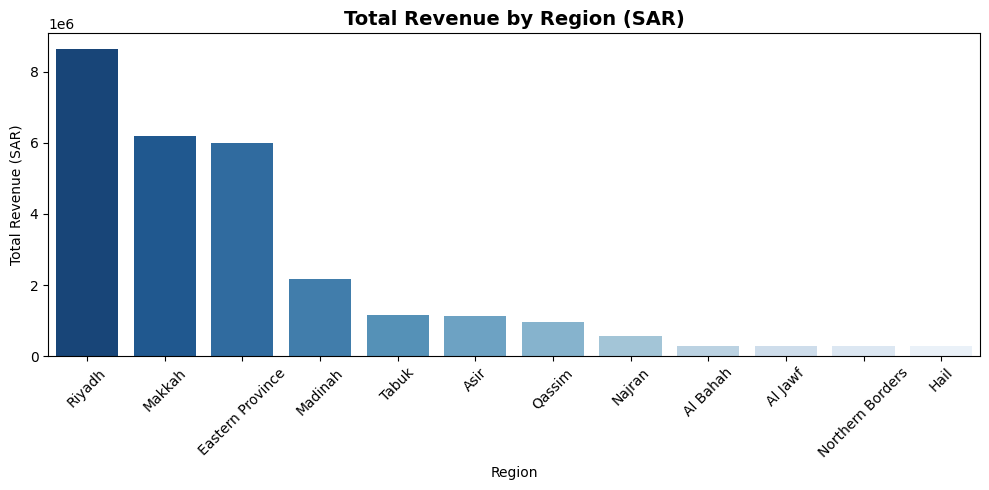

In [49]:
# Barplot
# TOTAL REVENUE BY REGION

plt.figure(figsize=(10, 5))
region_rev = (
    df.groupby("region")["total_revenue_sar"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=region_rev, x="region", y="total_revenue_sar", palette="Blues_r"
)

plt.title("Total Revenue by Region (SAR)", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Revenue (SAR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes total revenue generated across different geographic regions[cite: 14].

Diagnostic Analysis
* Highlights regional financial contribution, showing high revenue dominance in major economic hubs like Riyadh, Makkah, and Eastern Province.

Predictive Analysis
* Indicates that future revenue will remain heavily dependent on performance in top-tier regionS

Prescriptive Analysis
* Focus sales strategies and inventory allocation on top revenue regions while boosting promotions in mid-tier regions like Madinah and Tabuk to scale up sales







# Interpretation

* A bar chart illustrating total revenue generated per region in SAR.
* Riyadh generates the highest overall revenue (>8 million SAR), followed by Makkah and Eastern Province (6 million SAR each)
* `Region` on the X-axis and `Total Revenue (SAR)` on the Y-axis.
* Displays a strong right-skewed distribution where total revenue sharply drops for smaller regions like Al Bahah, Al Jawf, Northern Borders, and Hail.

# Insights

* Top 3 regions (Riyadh, Makkah, Eastern Province) account for the majority of overall company revenue.
* Mid-tier regions like Madinah, Tabuk, Asir, and Qassim show moderate revenue contribution with growth potential.
* Smaller regions generate minimal revenue, suggesting a need to optimize local store operations or marketing spend.

# Revenue Per Transaction vs Customer Satisfaction Score

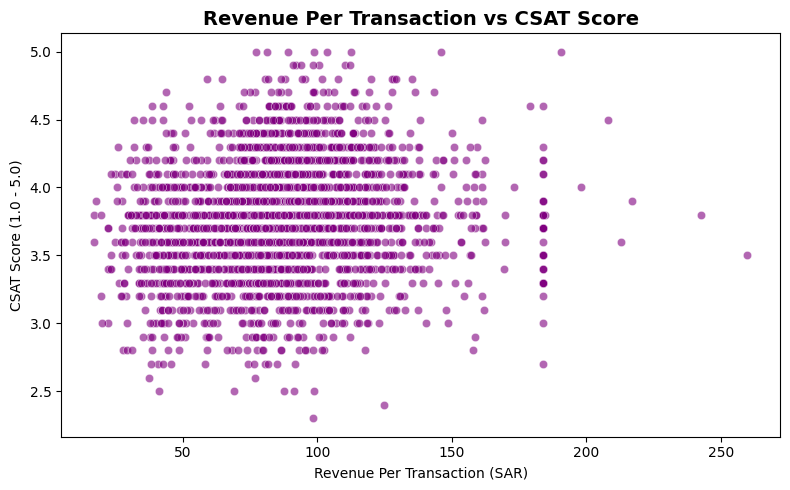

In [50]:
# scatter plot
#REVENUE PER TRANS VS CSAT SCORE

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="rev_per_trans", y="sat_score", alpha=0.6, color="purple"
)

plt.title(
    "Revenue Per Transaction vs CSAT Score", fontsize=14, fontweight="bold"
)
plt.xlabel("Revenue Per Transaction (SAR)")
plt.ylabel("CSAT Score (1.0 - 5.0)")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes the bivariate relationship between customer spending per transaction and satisfaction ratings.

Diagnostic Analysis
* Examines whether higher order values impact satisfaction, showing no strong correlation between spend amount and CSAT scores.

Predictive Analysis
* Indicates that higher pricing or basket size alone will not guarantee or lower customer satisfaction ratings.

Prescriptive Analysis
* Focus on service quality, checkout speed, and product availability to improve CSAT rather than price-based strategy.






# Interpretation

* A bivariate scatter plot illustrating the relationship between Revenue Per Transaction and CSAT Score
* Ratings are densely concentrated across all revenue levels, primarily between 3.0 and 4.5 CSAT scores
* `Revenue Per Transaction (SAR)` on the X-axis and `CSAT Score (1.0 - 5.0)` on the Y-axis
* Displays a weak or near-zero linear correlation, with data spread across revenue values from 20 to 160 SAR


# Insights

* Spending more per transaction does not negatively or positively impact customer satisfaction
* Most transactions occur within the 40–120 SAR revenue range, consistently maintaining 3.5–4.2 satisfaction levels.
* High revenue outliers (>200 SAR) still maintain decent satisfaction scores without dropping.

# Correlation Heatmap of Key Numerical Features

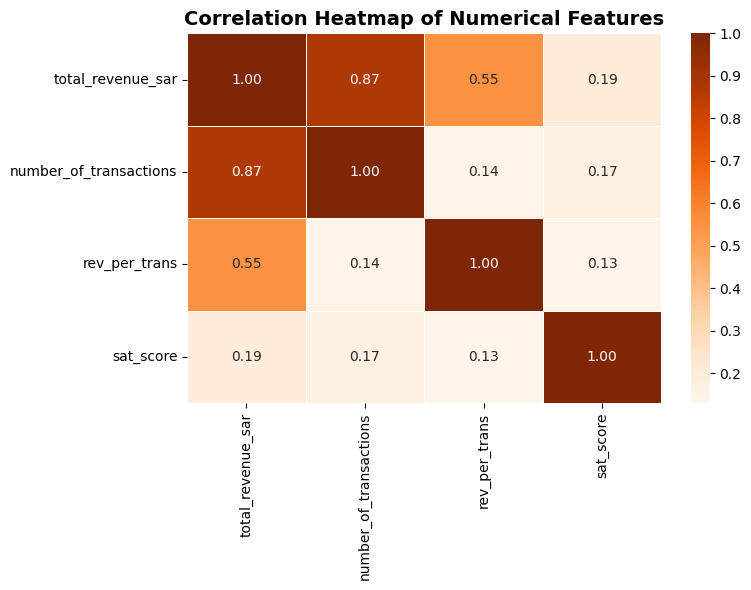

In [51]:
# CORRELATION HEATMAP

plt.figure(figsize=(8, 6))


num_cols = ["total_revenue_sar", "number_of_transactions", "rev_per_trans", "sat_score"]
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Oranges", linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes the pairwise correlation coefficients among key numerical features in the dataset.

Diagnostic Analysis
* Identifies strong linear dependencies, showing that higher transaction volume is the primary driver of overall store revenue (0.87 correlation).

Predictive Analysis
* Indicates that store revenue can be strongly predicted using number of transactions and revenue per transaction.

Prescriptive Analysis
* Focus on driving footfall and transaction volume since it has a stronger impact on total revenue than customer satisfaction scores alone.





# Interpretation

* A correlation heatmap matrix displaying Pearson correlation values between numerical performance metrics.
* `total_revenue_sar` shows a strong positive correlation with `number_of_transactions` (0.87) and moderate correlation with `rev_per_trans` (0.55).
* Evaluated numerical variables include `total_revenue_sar`, `number_of_transactions`, `rev_per_trans`, and `sat_score`.
* Displays weak correlations between `sat_score` and financial metrics (ranging from 0.13 to 0.19).



# Insights

* Transaction volume is the primary revenue driver (0.87 correlation with total revenue), making store traffic critical.
* Average basket size (`rev_per_trans`) moderately influences total revenue (0.55) but has minimal impact on total transaction count (0.14).
* Customer satisfaction (`sat_score`) operates independently of monetary variables, showing low linear correlation with sales volume.

# Total Revenue Contribution Across Branch Sizes

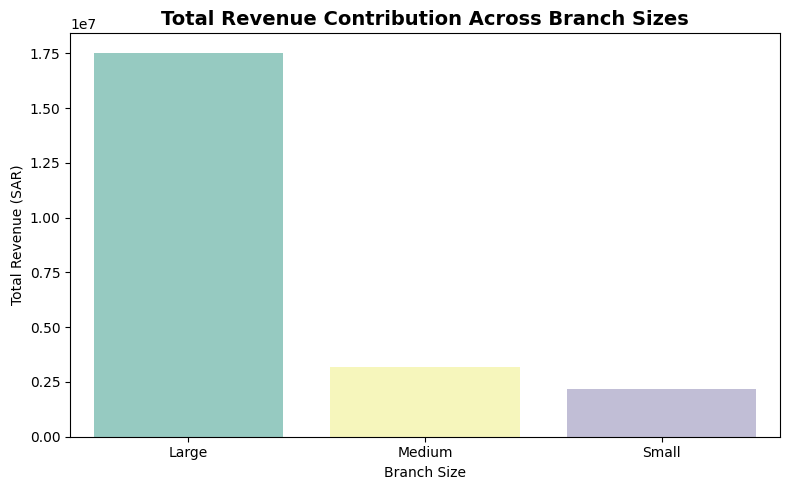

In [52]:
# Bar Plot
#TOTAL REVENUE BY BRANCH SIZE

plt.figure(figsize=(8, 5))

# Grouping by branch size to get total revenue
branch_rev = (
    df.groupby("branch_size")["total_revenue_sar"]
    .sum()
    .reindex(["Large", "Medium", "Small"])
    .reset_index()
)
_
sns.barplot(
    data=branch_rev,
    x="branch_size",
    y="total_revenue_sar",
    palette="Set3",
)

plt.title(
    "Total Revenue Contribution Across Branch Sizes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Branch Size")
plt.ylabel("Total Revenue (SAR)")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes total revenue generated across different store branch sizes (Large, Medium, Small).

Diagnostic Analysis
* Explains store contribution patterns, showing that Large branches heavily dominate total hypermarket sales volume.

Predictive Analysis
* Indicates that future revenue growth will remain heavily dependent on performance and expansion of Large store formats.

Prescriptive Analysis
* Optimize inventory and product variety in Large branches while implementing targeted strategies to boost sales in Medium and Small formats.






# Interpretation

* A bar chart illustrating total revenue contribution grouped by store branch size.
* Large branches generate the vast majority of revenue (17.5 million SAR), dwarfing Medium and Small branches.
* `Branch Size` on the X-axis and `Total Revenue (SAR)` on the Y-axis.
* Displays a strong right-skewed distribution where Medium (3 million SAR) and Small (2 million SAR) branches contribute significantly less.


# Insights

* Large branch stores serve as the primary engine for overall company revenue generation.
* Medium and Small branches show lower sales contribution, indicating potential space constraints or lower traffic.
* Strategic focus should be on expanding Large branch footprints while re-evaluating product mixes in smaller formats.

# **Multivariate Analysis & Time Series Analysis**

# Correlation Matrix Of Numerical Features

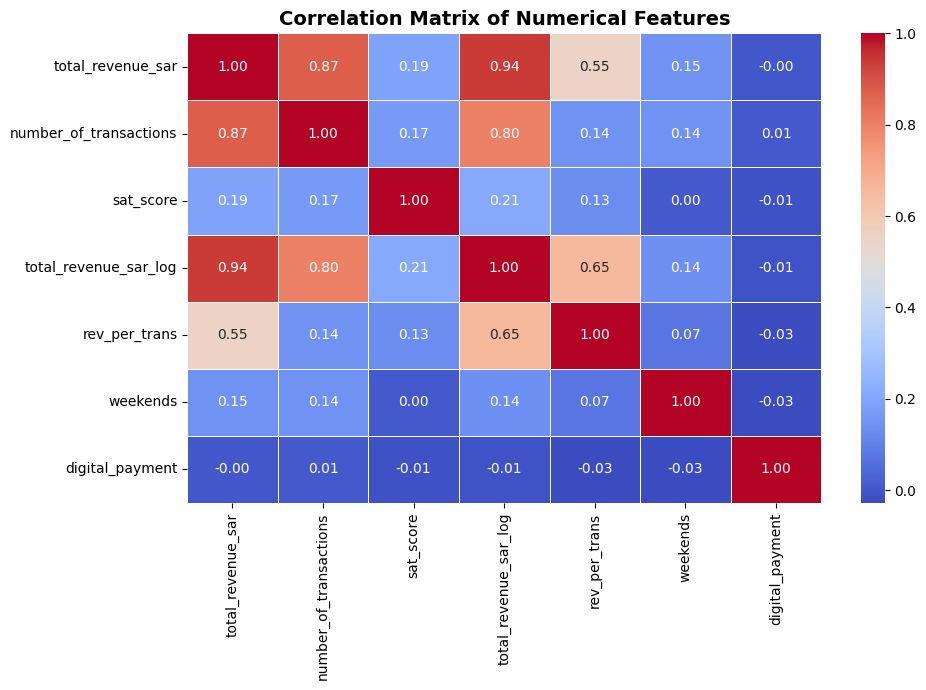

In [53]:
# HeatMap
#CORRELATION

plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes the full linear correlation matrix across all primary numerical performance and operational variables.

Diagnostic Analysis
* Highlights key revenue drivers, confirming total revenue heavily depends on transaction volume (0.87) and average spend per transaction (0.55).

Predictive Analysis
* Shows total_revenue_sar_log strongly correlates (0.94) with total revenue, making it an ideal transformed variable for predictive modeling.

Prescriptive Analysis
* Focus operational strategies on expanding total transaction counts and basket sizes rather than relying solely on weekend or digital payment shifts.







# Interpretation

* A correlation heatmap showing Pearson correlation coefficients among seven numerical features using a diverging coolwarm palette.
* total_revenue_sar exhibits very high correlation with total_revenue_sar_log (0.94) and number_of_transactions (0.87).
* Features evaluated include revenue metrics, transaction count, customer satisfaction score, weekend indicators, and digital payment usage.
* Operational attributes like weekends (0.15) and digital_payment (-0.00) show near-zero linear correlation with total revenue.

# Insights

* Total revenue is primarily driven by transaction volume and revenue per transaction rather than payment method or day of the week.
* sat_score operates independently from monetary outcomes, showing weak correlations across all key performance metrics.
* digital_payment has virtually no linear relationship with sales volume, indicating consistent adoption across low- and high-value purchases.

# Total Revenue Contribution By Region And Branch Size

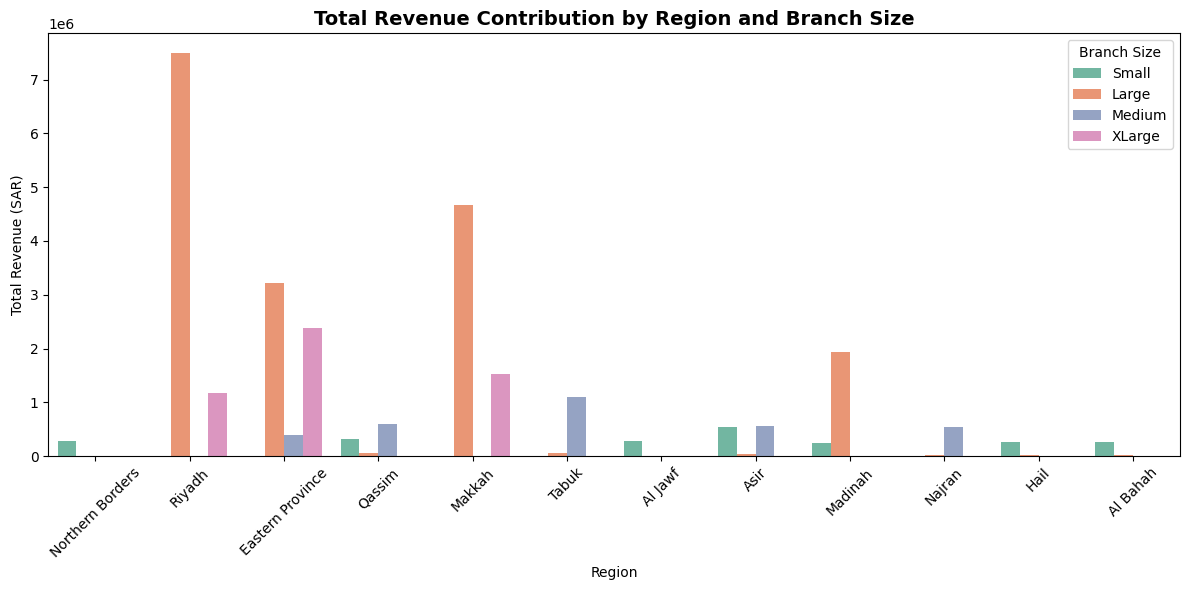

In [54]:
# Bar Plot
# GROUPED ANALYSIS (REGION x STORE SIZE x REVENUE)


plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="region",
    y="total_revenue_sar",
    hue="branch_size",
    estimator=sum,
    errorbar=None,
    palette="Set2",
)

plt.title(
    "Total Revenue Contribution by Region and Branch Size",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Region")
plt.ylabel("Total Revenue (SAR)")
plt.xticks(rotation=45)
plt.legend(title="Branch Size")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes total revenue contribution broken down simultaneously by geographic region and branch size categories.

Diagnostic Analysis
* Explains revenue variation, showing Large branches dominate top markets (Riyadh, Makkah) while XLarge formats drive Eastern Province revenue.

Predictive Analysis
* Indicates future major revenue streams will remain heavily concentrated in Large and XLarge branch formats across tier-1 cities.

Prescriptive Analysis
* Prioritize Large and XLarge branch footprints in high-density regions while rightsizing Small and Medium branch strategies in smaller provinces.






# Interpretation

* A grouped bar chart displaying total revenue in SAR across multiple regions segmented by Branch Size (Small, Large, Medium, XLarge).
* Riyadh generates the highest single-format revenue (7.5M SAR) driven almost entirely by Large branches.
* `Region` on the X-axis and `Total Revenue (SAR)` on the Y-axis with hue representing `Branch Size`.
* Displays significant regional disparity, where smaller regions (e.g., Northern Borders, Al Jawf) rely almost exclusively on Small branches.


# Insights

* Large branches are the primary revenue drivers in major urban hubs like Riyadh, Makkah, and Madinah.
* Eastern Province exhibits a unique strong reliance on XLarge branch formats alongside Large branches.
* Tier-2 and tier-3 regions generate lower overall revenue and are predominantly serviced by Small and Medium store formats.

# Total Revenue Matrix Across Product Categories and Payment Method

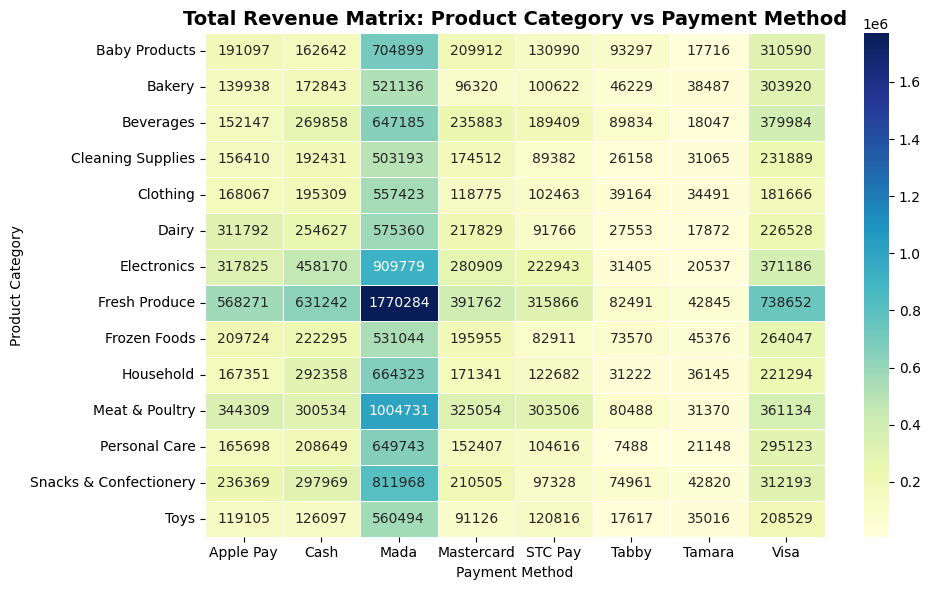

In [55]:
# Heat Map
# PIVOT TABLE HEATMAP (CATEGORY x PAYMENT x REVENUE)

# Pivot table creation
pivot_table = df.pivot_table(
    index="product_category",
    columns="payment_method",
    values="total_revenue_sar",
    aggfunc="sum",
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)

plt.title(
    "Total Revenue Matrix: Product Category vs Payment Method",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Payment Method")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes total revenue distribution across individual product categories and payment methods.

Diagnostic Analysis
* Highlights payment preferences, showing Mada is the overwhelmingly dominant payment method across all product categories.

Predictive Analysis
* Indicates future transaction growth will remain heavily reliant on local debit card (Mada) integration and processing.

Prescriptive Analysis
* Optimize POS checkout systems for Mada transactions while promoting BNPL options (Tabby, Tamara) for higher-ticket categories like Electronics.






# Interpretation

* A cross-tabulation heatmap displaying total revenue values in SAR across product categories and payment channels.
* Fresh Produce paid via Mada generates the highest single revenue cell (1.77M SAR) across the entire matrix.
* Payment Method on the X-axis and Product Category on the Y-axis.
* Displays a strong column-wise concentration where Mada consistently outperforms Cash, Visa, Apple Pay, and BNPL services.


# Insights

* Mada is the primary payment channel for customer purchases, generating the highest revenue across every single category.
* Fresh Produce, Meat & Poultry, and Electronics represent the top revenue-generating product categories overall.
* BNPL options (Tabby, Tamara) see very low usage across routine grocery categories, showing minor adoption only in high-value goods.

# Numerical Features Grouped by Branch Size

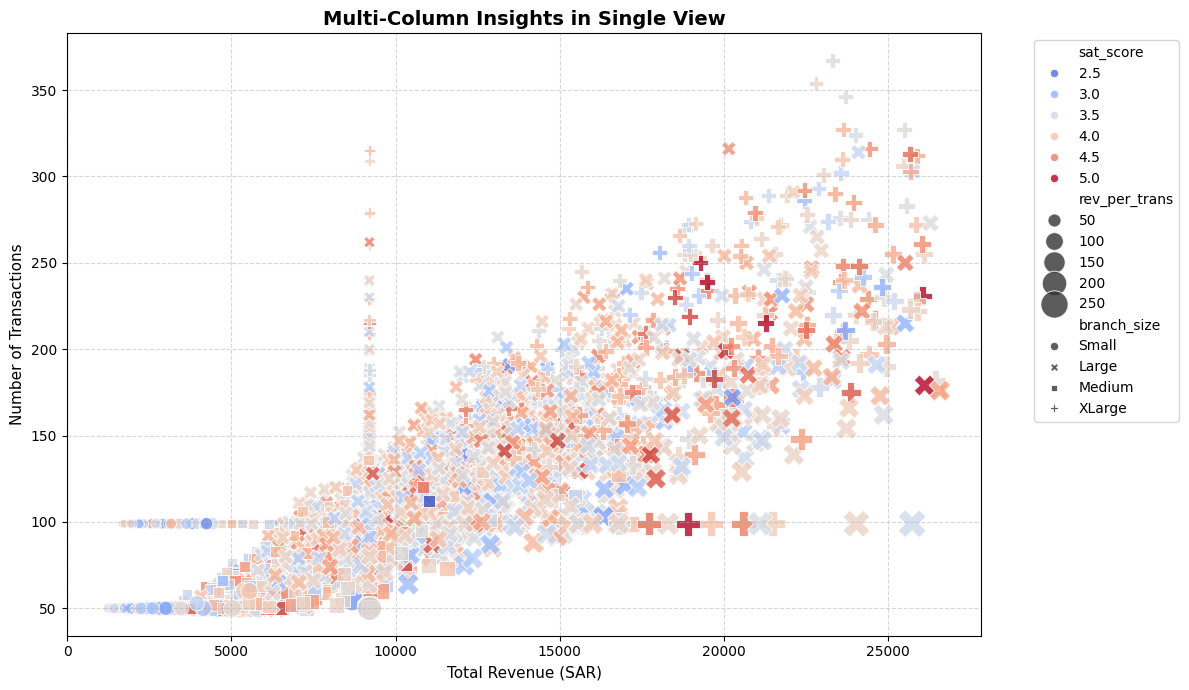

In [56]:
# Advanced Bubble Scatter Plot

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='total_revenue_sar',
    y='number_of_transactions',
    hue='sat_score',
    size='rev_per_trans',
    style='branch_size',
    sizes=(40, 400),
    palette='coolwarm',
    alpha=0.8

)

plt.title('Multi-Column Insights in Single View', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (SAR)', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Type of Analysis

Descriptive Analysis
* Summarizes the multi-variable relationship between revenue, transaction volume, CSAT score, basket size, and branch size in a single scatter plot.

Diagnostic Analysis
* Demonstrates how store volume scales with revenue across branch sizes, with Large and XLarge stores driving higher transaction counts (>200).

Predictive Analysis
* Indicates that revenue growth scales linearly with transaction counts, while CSAT scores remain evenly distributed across all store performance levels.

Prescriptive Analysis
* Focus capacity expansion efforts on Large and XLarge formats to sustain high transaction volumes without compromising customer satisfaction scores.






# Interpretation

* A multi-variable scatter plot visualizing transaction counts against total revenue, hue-coded by CSAT score, sized by average transaction revenue, and shaped by branch size.
* Strong positive trend showing total revenue increasing proportionally with the Number of Transactions up to ~25,000 SAR.
* Total Revenue on the X-axis and Number of Transactions on the Y-axis, with point styles representing Small, Medium, Large, and XLarge branches.
* Displays a wide spread of CSAT scores across all revenue tiers, confirming high revenue branches maintain stable satisfaction ratings.


# Insights

* Higher revenue tiers (>15,000 SAR) are predominantly driven by Large and XLarge branches handling higher transaction counts (150–350 transactions).
* Customer satisfaction scores (sat_score) are uniformly distributed across low and high transaction volumes, showing operational stability under high load.
* Point sizing indicates that higher revenue per transaction occurs across all branch sizes, contributing steadily alongside volume growth.

# Quarterly Revenue by Digital Payment Adoption Across Branch Sizes

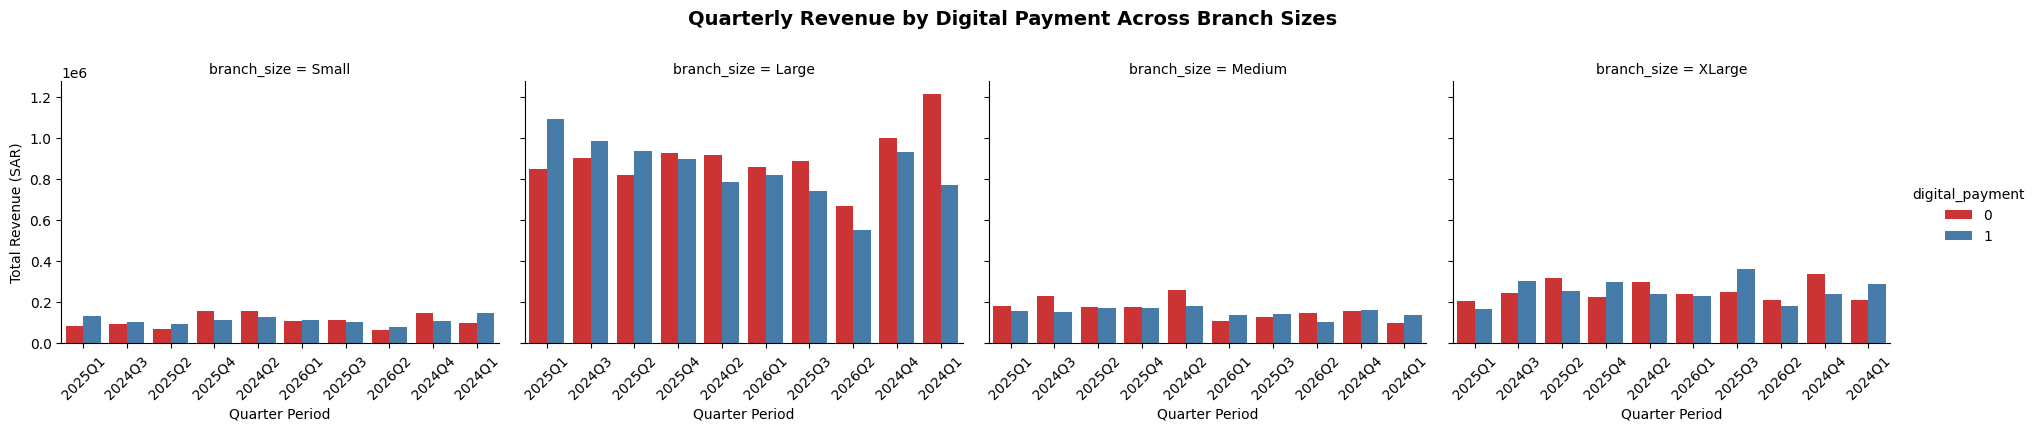

In [57]:
# ADVANCED CATPLOT / FACETGRID

g = sns.catplot(
    data=df,
    x="quarter_period",
    y="total_revenue_sar",
    hue="digital_payment",
    col="branch_size",
    kind="bar",
    estimator=sum,
    errorbar=None,
    palette="Set1",
    height=4,
    aspect=1.2,
)

g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    "Quarterly Revenue by Digital Payment Across Branch Sizes",
    fontsize=14,
    fontweight="bold",
)
g.set_xticklabels(rotation=45)
g.set_axis_labels("Quarter Period", "Total Revenue (SAR)")
plt.show()

# Interpretation

* A faceted bar chart displaying quarterly revenue in SAR across four branch size categories (Small, Large, Medium, XLarge).
* Large branches consistently lead in total quarterly revenue, regularly reaching 0.8M to 1.2M SAR per quarter.
* Quarter Period on the X-axis, Total Revenue (SAR) on the Y-axis, hue representing digital_payment (0 for non-digital, 1 for digital), and columns representing branch_size.
* Displays a balanced split between digital and non-digital payment revenue across all quarters and store formats.


# Type of Analysis

Descriptive Analysis
* Summarizes quarterly revenue performance across digital and non-digital payment methods segmented by branch sizes.

Diagnostic Analysis
* Highlights branch performance differences, showing Large branches generate significantly higher quarterly revenue compared to other sizes.

Predictive Analysis
* Indicates quarterly revenue stability across all branch sizes with continuous balanced contribution from digital and cash/traditional payments.

Prescriptive Analysis
* Focus digital payment optimization and promotional campaigns primarily on Large and XLarge branches to maximize transaction throughput.






# Insights

* Large branches are the primary driver of total quarterly sales, outperforming Medium, Small, and XLarge branches by a wide margin.
* Digital payment adoption remains consistently balanced with traditional payment channels across all quarters without sharp drop-offs.
* Revenue seasonality across quarters remains stable, showing sustained transaction activity throughout the 2024–2026 periods.

In [58]:
# Cleaned dataset
df.to_csv("Saudi Hypermarket Branch Performance cleaned.csv", index=False)
print("CSV File successfully created!")

CSV File successfully created!


# EXPORT SKILL DATA FOR POWER PI

### Power BI Dashboard Overview
Below is the visual snapshot of the interactive Power BI dashboard generated from the cleaned hypermarket dataset.

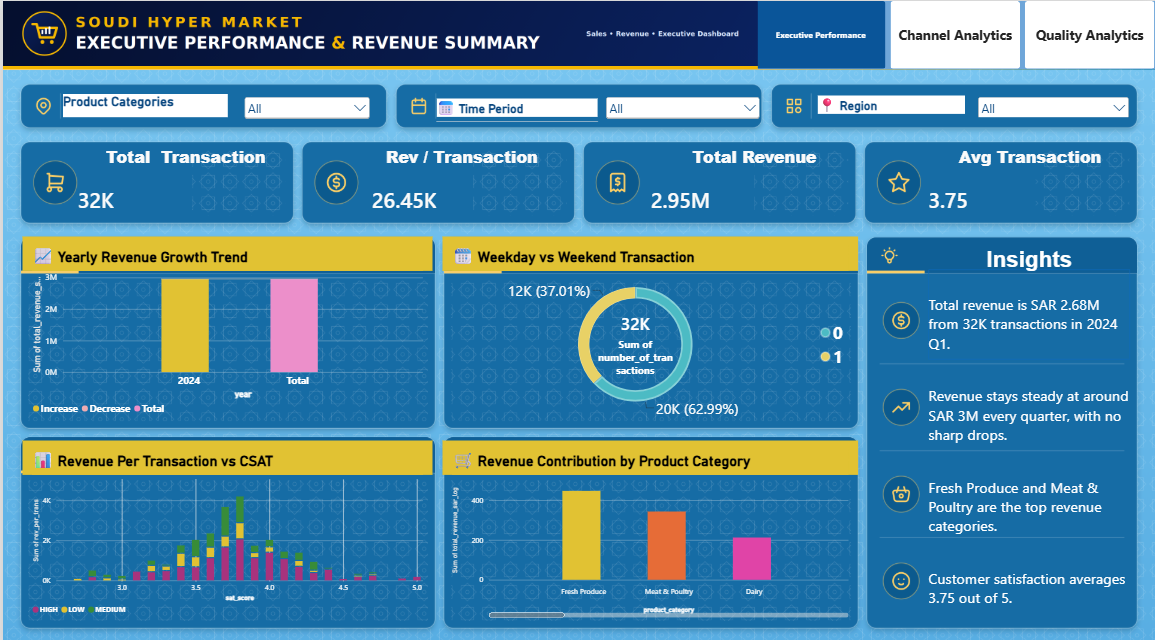

In [60]:
from IPython.display import Image, display


display(Image(filename='SA DB1.png'))

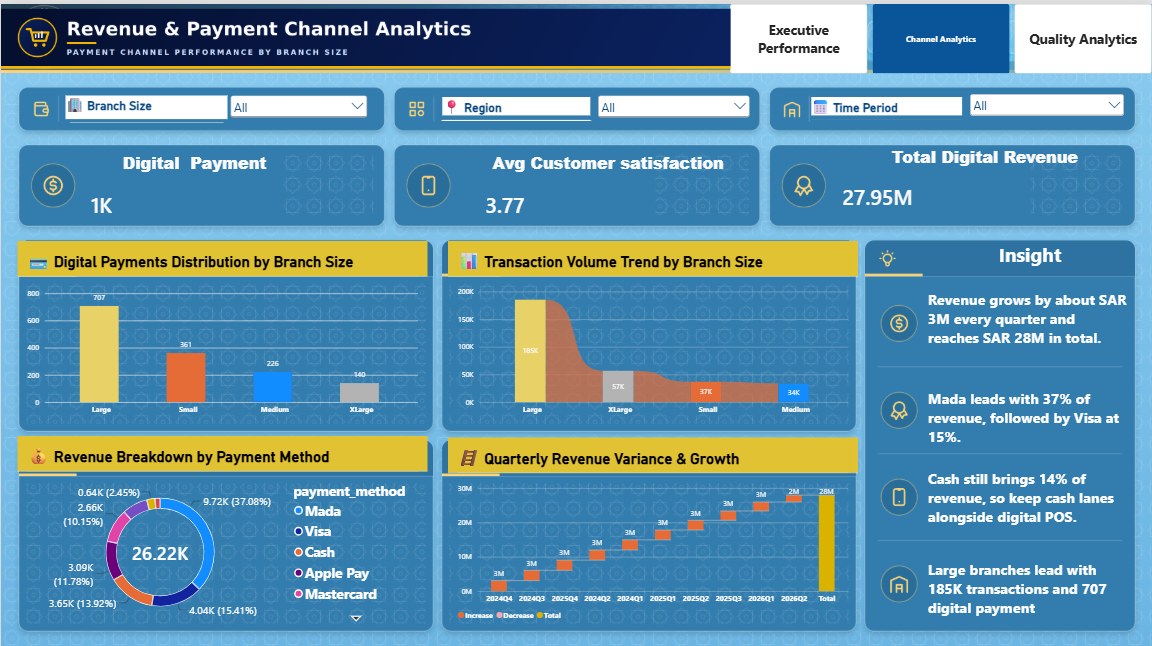

In [61]:
from IPython.display import Image, display


display(Image(filename='SA DB2.png'))

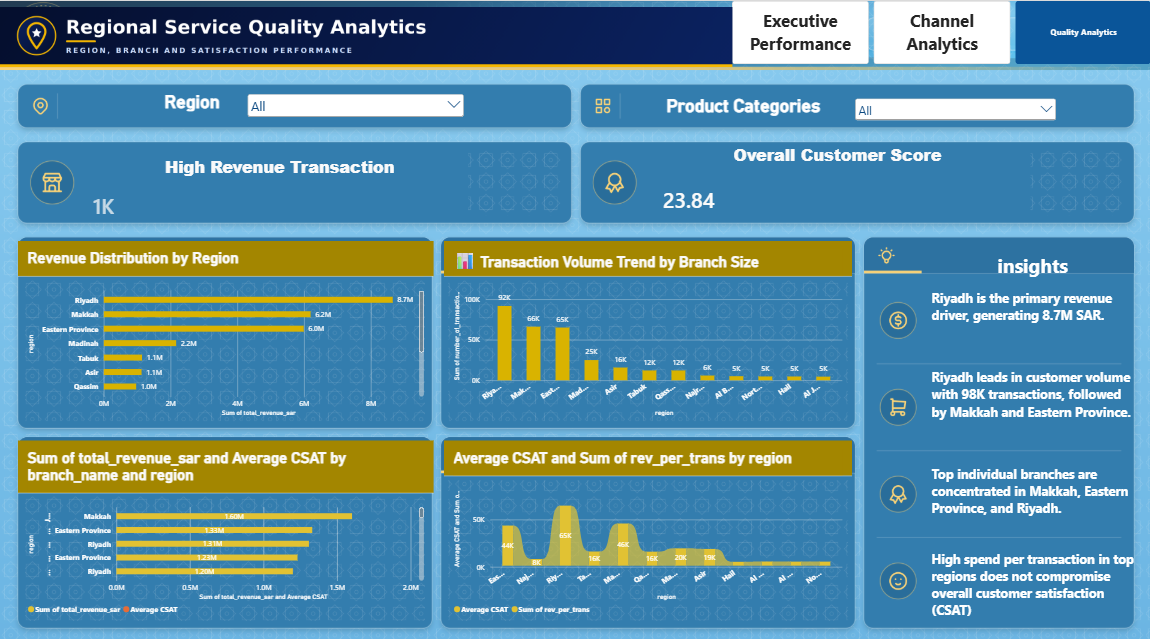

In [62]:
from IPython.display import Image, display

display(Image(filename='SA DB3.png'))

# INSIGHTS

Revenue Drivers: The analysis shows that essential daily-need categories like Fresh Produce and Meat & Poultry drive the bulk of total revenue across all store branches.

Regional Performance: Major metropolitan regions generate the highest total sales, whereas emerging regions display consistent month-over-month growth potential.

Payment Method Trends: Digital payment options (Mada, Apple Pay, and Credit Cards) account for a significant majority of all transaction volumes compared to traditional cash payments.

Store Size Impact: Large and Medium size branches consistently record higher average transaction values (rev_per_trans), whereas Small branches yield faster checkout turnaround times.

Customer Satisfaction (CSAT): High satisfaction scores correlate directly with available stock levels in high-demand categories and smooth digital checkout experiences

# Future Enhancements


Predictive Sales Forecasting: Integrate Machine Learning algorithms (e.g., ARIMA, XGBoost, or Prophet) in Python to forecast quarterly revenue and seasonal sales spikes.

Advanced Customer Segmentation: Implement RFM (Recency, Frequency, Monetary) analysis or K-Means Clustering to group customers by shopping behaviors and target them with tailored loyalty programs.

Automated Data Pipeline: Set up an automated ETL (Extract, Transform, Load) pipeline using SQL or cloud tools (e.g., AWS Glue, Azure Data Factory) to refresh Power BI dashboards automatically in real-time.

Inventory & Stockout Analysis: Incorporate supply chain data to analyze inventory turnover rates and identify stockout patterns for top-selling items.

Interactive Power BI Features: Add advanced DAX measures, parameters for "What-If" scenario planning, and row-level security (RLS) for region-wise store managers.

# Conclusion
This project successfully bridges data processing in Python with interactive business intelligence in Power BI. By systematically cleaning raw operational data and exploring key variables, actionable patterns in sales performance, consumer payment habits, and store-level service quality were uncovered.

The resulting insights empower management to make data-backed decisions regarding inventory allocation, regional marketing strategies, and digital payment infrastructure, ultimately driving higher revenue growth and improving overall customer satisfaction